In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("merged_small.csv", low_memory=False)

print("Rows:", len(df))


Rows: 5000


In [18]:
df['Incident Date'] = pd.to_datetime(df['Incident Date'], dayfirst=True, errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

df['Combined Date'] = df['Incident Date'].fillna(df['Date'])
df['Year'] = df['Combined Date'].dt.year
print("Full datset year rannge:",df['Year'].min(),"-",df['Year'].max())



Full datset year rannge: 2003 - 2026


C:\Users\nandu\AppData\Local\Temp\ipykernel_17924\3471618886.py:2: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')


In [3]:
df = df[(df['Year'] >= 2003) & (df['Year'] <= 2025)]

print("Filtered range:", df['Year'].min(), "-", df['Year'].max())

Filtered range: 2003.0 - 2025.0


In [4]:
df['Category_All'] = df['Incident Category'].fillna(df['Category'])

print(df['Category_All'].value_counts().head(20))

Category_All
Larceny Theft          293262
LARCENY/THEFT          182450
OTHER OFFENSES         121992
NON-CRIMINAL            72756
Other Miscellaneous     68972
Malicious Mischief      68325
ASSAULT                 66155
Assault                 64549
Burglary                55881
Motor Vehicle Theft     54801
VEHICLE THEFT           49490
DRUG/NARCOTIC           49088
VANDALISM               45044
Recovered Vehicle       40242
WARRANTS                39985
Non-Criminal            37921
BURGLARY                34957
Fraud                   33692
Warrant                 32980
SUSPICIOUS OCC          32232
Name: count, dtype: int64


In [5]:
focus_crimes = [
    'LARCENY THEFT',
    'ASSAULT',
    'BURGLARY',
    'MOTOR VEHICLE THEFT',
    'ROBBERY'
]

In [6]:
df_focus = df[df['Category_All'].isin(focus_crimes)]

print("df_focus year range:", df_focus['Year'].min(), "-", df_focus['Year'].max())

df_focus year range: 2003.0 - 2018.0


In [7]:
yearly_counts = (
    df_focus
    .groupby(['Year', 'Category_All'])
    .size()
    .reset_index(name='Total Incidents')
)
print(f"Year range: {yearly_counts['Year'].min()} - {yearly_counts['Year'].max()}")
#print("Year range:", yearly_counts['Year'].min(), "-", yearly_counts['Year'].max())
yearly_counts.head()

Year range: 2003.0 - 2018.0


,Year,Category_All,Total Incidents
0,2003.0,ASSAULT,4541
1,2003.0,BURGLARY,2319
2,2003.0,ROBBERY,1253
3,2004.0,ASSAULT,4416
4,2004.0,BURGLARY,2573


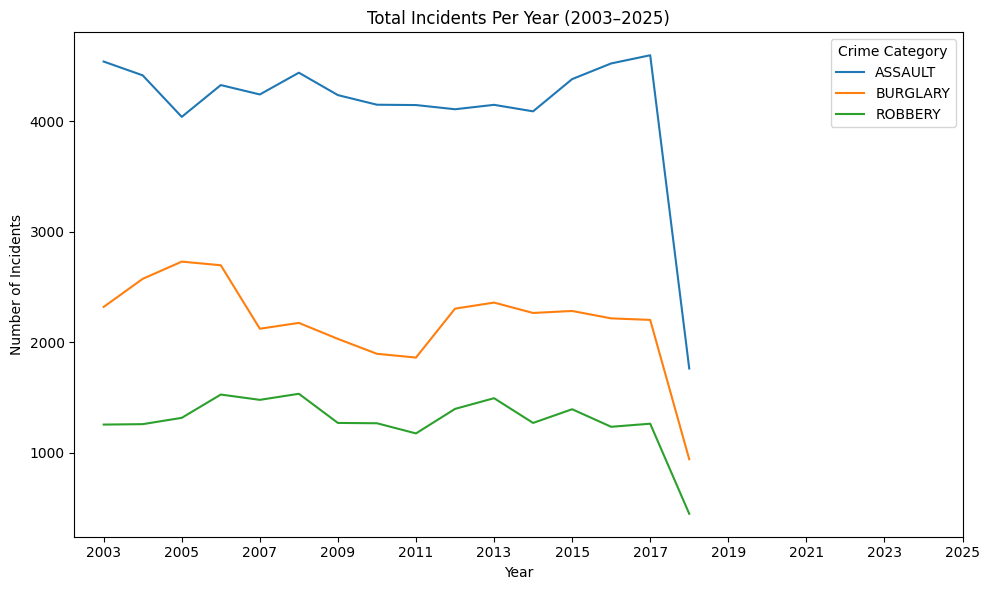

In [8]:
#import matplotlib.pyplot as plt
#import seaborn as sns

plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_counts,
    x='Year',
    y='Total Incidents',
    hue='Category_All'
)

plt.title("Total Incidents Per Year (2003–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.xticks(range(2003, 2026, 2))
plt.legend(title="Crime Category")
plt.tight_layout()
plt.show()

In [9]:
df_focus['District_All'] = df_focus['Police District'].fillna(df_focus['PdDistrict'])
df_focus['District_All'] = df_focus['District_All'].str.upper()
print(df_focus['District_All'].unique())

<StringArray>
[  'SOUTHERN',  'INGLESIDE',       'PARK',    'BAYVIEW',   'NORTHERN',
    'CENTRAL',    'TARAVAL', 'TENDERLOIN',    'MISSION',   'RICHMOND']
Length: 10, dtype: str


In [10]:
city_totals = df_focus['Category_All'].value_counts(normalize=True)

print(city_totals)

Category_All
ASSAULT     0.543761
BURGLARY    0.287329
ROBBERY     0.168911
Name: proportion, dtype: float64


In [11]:
district_totals = (
    df_focus
    .groupby('District_All')['Category_All']
    .value_counts(normalize=True)
    .unstack()
)

In [12]:
print(district_totals.columns)

Index(['ASSAULT', 'BURGLARY', 'ROBBERY'], dtype='str', name='Category_All')


In [13]:
focus_crimes = [
    'LARCENY/THEFT',
    'ASSAULT',
    'BURGLARY',
    'VEHICLE THEFT',
    'ROBBERY'
]

In [14]:
ratio = district_totals.div(city_totals, axis=1)

ratio.head()

Category_All,ASSAULT,BURGLARY,ROBBERY
District_All,,,
BAYVIEW,1.042876,0.909921,1.015203
CENTRAL,0.942171,1.159649,0.914590
INGLESIDE,1.020305,0.903475,1.098831
MISSION,1.075387,0.756353,1.171772
NORTHERN,0.887737,1.266725,0.907683


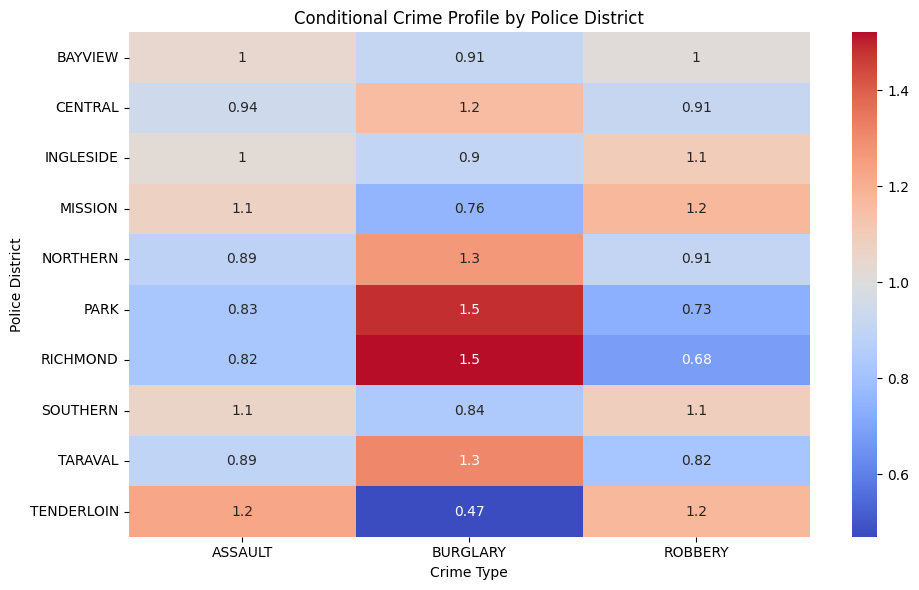

In [15]:
plt.figure(figsize=(10,6))

sns.heatmap(ratio, annot=True, cmap='coolwarm', center=1)

plt.title("Conditional Crime Profile by Police District")
plt.xlabel("Crime Type")
plt.ylabel("Police District")
plt.tight_layout()
plt.show()


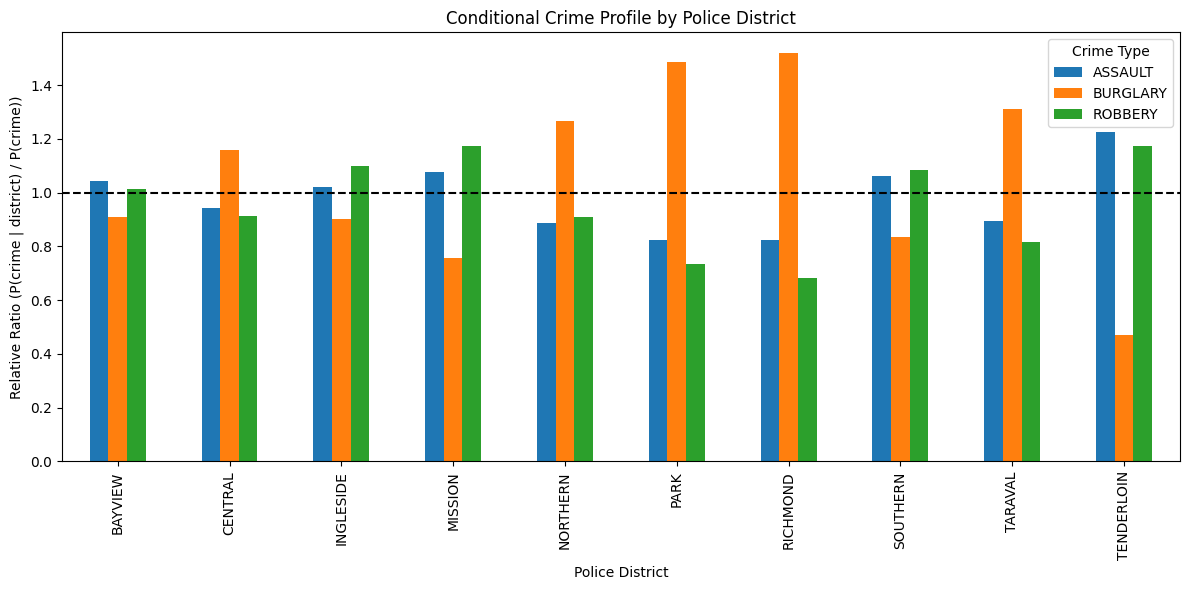

In [16]:


# Make sure district names are consistent
ratio.index = ratio.index.str.upper()

ratio.plot(kind='bar', figsize=(12,6))

plt.title("Conditional Crime Profile by Police District")
plt.xlabel("Police District")
plt.ylabel("Relative Ratio (P(crime | district) / P(crime))")
plt.axhline(1, color='black', linestyle='--')  # baseline
plt.legend(title="Crime Type")
plt.tight_layout()
plt.show()